Phase 1: Load & Explore Data (Python + Pandas)

Objective: Inspect the dataset and prepare it for analysis.

In [30]:
import pandas as pd 
df = pd.read_csv("space_environment_dataset.csv")

Inspecting the data

In [31]:
df.head()
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Day                     365 non-null    int64  
 1   Solar_Flare_Occurred    365 non-null    int64  
 2   Micrometeoroid_Impacts  365 non-null    int64  
 3   Radiation_Level_mSv     365 non-null    float64
 4   Surface_Temperature_C   365 non-null    float64
 5   Solar_Wind_Speed_km_s   365 non-null    float64
dtypes: float64(3), int64(3)
memory usage: 17.2 KB


,Day,Solar_Flare_Occurred,Micrometeoroid_Impacts,Radiation_Level_mSv,Surface_Temperature_C,Solar_Wind_Speed_km_s
count,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000
mean,183.000000,0.287671,5.010959,49.430217,20.287253,395.893615
std,105.510663,0.453298,2.211332,9.823547,4.906922,48.707758
min,1.000000,0.000000,0.000000,15.285701,6.576060,233.762214
25%,92.000000,0.000000,3.000000,42.765372,16.683478,364.756577
50%,183.000000,0.000000,5.000000,49.802509,20.528747,393.259956
75%,274.000000,1.000000,7.000000,56.385179,23.755654,426.945959
max,365.000000,1.000000,11.000000,76.342220,35.309735,534.233712


Filter dataset for one week (first 7 days):

In [32]:
week_data = df[df['Day'].between(1,7)]

Convert Solar_Flare_Occurred to integer

In [33]:
df['Solar_Flare_Occurred'] = df['Solar_Flare_Occurred'].astype(int)

Phase 2: Basic Statistics & NumPy Practice

Objective: Compute descriptive statistics and understand distributions.

In [34]:
import numpy as np
from math import comb


df.mean()


Day                       183.000000
Solar_Flare_Occurred        0.287671
Micrometeoroid_Impacts      5.010959
Radiation_Level_mSv        49.430217
Surface_Temperature_C      20.287253
Solar_Wind_Speed_km_s     395.893615
dtype: float64

In [35]:
df.std()

Day                       105.510663
Solar_Flare_Occurred        0.453298
Micrometeoroid_Impacts      2.211332
Radiation_Level_mSv         9.823547
Surface_Temperature_C       4.906922
Solar_Wind_Speed_km_s      48.707758
dtype: float64

Binomial Distribution (Solar Flares)

Solar flares are binary events.

This gives the daily probability of a flare.

The probability model follows the Binomial Distribution.

Solar Flare Occurrence Rate: 0.29


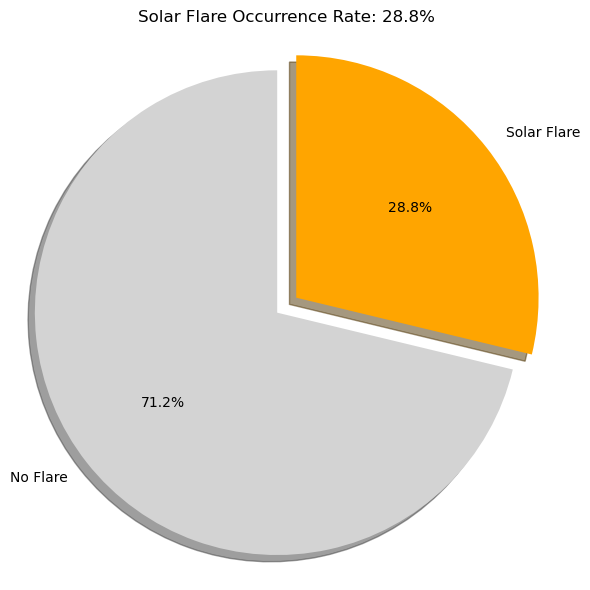

In [41]:

P = df['Solar_Flare_Occurred'].mean()
print(f"Solar Flare Occurrence Rate: {P:.2f}")

# Create a pie chart
plt.figure(figsize=(6, 6))
flare_count = df['Solar_Flare_Occurred'].sum()
no_flare_count = len(df) - flare_count
sizes = [no_flare_count, flare_count]
colors = ['lightgray', 'orange']
explode = (0, 0.1)  # "explode" the flare slice

plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', startangle=90, shadow=True)
plt.title(f'Solar Flare Occurrence Rate: {p*100:.1f}%')
plt.axis('equal')  # Equal aspect ratio ensures pie is circular
plt.tight_layout()
plt.show()



Probability of exactly 3 flares in 7 days: 0.2145
Or as percentage: 21.45%


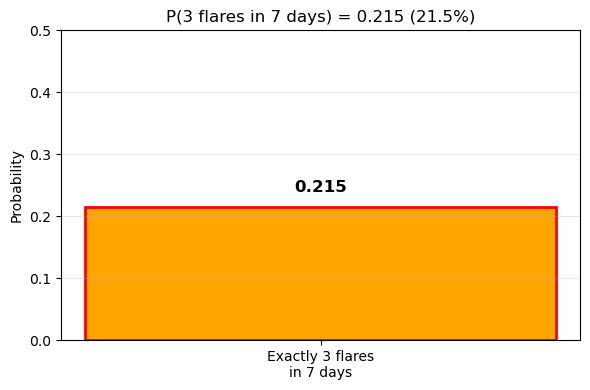

In [39]:
# Binomial probability for exactly 3 flares in 7 days
n = 7  # number of days
k = 3  # number of flares we want

# Calculate using formula: C(n,k) * p^k * (1-p)^(n-k)
probability = comb(n, k) * (P**k) * ((1-P)**(n-k))

print(f"\nProbability of exactly {k} flares in {n} days: {probability:.4f}")
print(f"Or as percentage: {probability*100:.2f}%")

import pandas as pd
import matplotlib.pyplot as plt
from math import comb
import numpy as np

# Load data and calculate probability
df = pd.read_csv('space_environment_dataset.csv')
p = df["Solar_Flare_Occurred"].mean()
n = 7
k = 3

# Calculate probability
probability = comb(n, k) * (p**k) * ((1-p)**(n-k))

# SIMPLE VISUALIZATION 1: Single bar chart
plt.figure(figsize=(6, 4))
plt.bar(['Exactly 3 flares\nin 7 days'], [probability], 
        color='orange', edgecolor='red', linewidth=2)
plt.ylabel('Probability')
plt.title(f'P(3 flares in 7 days) = {probability:.3f} ({probability*100:.1f}%)')
plt.ylim(0, 0.5)
plt.grid(True, axis='y', alpha=0.3)

# Add value on top of bar
plt.text(0, probability + 0.02, f'{probability:.3f}', 
         ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

Poisson Distribution (Micrometeoroid Impacts)
Impacts occur randomly.

Calculate the average rate:


In [42]:
lambda_val = df["Micrometeoroid_Impacts"].mean()
print(lambda_val)

5.010958904109589


the probability of 4 impacts occurring in a day

In [43]:
import pandas as pd
import numpy as np
from math import exp, factorial

# Load data and calculate lambda (average impacts per day)
df = pd.read_csv('space_environment_dataset.csv')
lambda_val = df["Micrometeoroid_Impacts"].mean()
k = 4  # number of impacts we want probability for

# Poisson formula: P(X=k) = (λ^k * e^(-λ)) / k!
probability = (lambda_val**k * exp(-lambda_val)) / factorial(k)

print("=" * 60)
print("POISSON PROBABILITY: MICROMETEOROID IMPACTS")
print("=" * 60)
print(f"Average impacts per day (λ): {lambda_val:.4f}")
print(f"Looking for probability of exactly {k} impacts in a day")
print(f"\nCalculated probability: {probability:.4f} ({probability*100:.2f}%)")

POISSON PROBABILITY: MICROMETEOROID IMPACTS
Average impacts per day (λ): 5.0110
Looking for probability of exactly 4 impacts in a day

Calculated probability: 0.1751 (17.51%)
